# MMM Calibration with Meridian ROI Priors

Google [Meridian](https://developers.google.com/meridian) calibrates a marketing
mix model by putting an experiment-informed prior on a channel's ROI. diff-diff
closes the loop from a geo experiment to that prior:
`results.aggregate('total')` gives the campaign's total incremental outcome in
the estimator's own units, `to_meridian_roi_prior` turns it into Meridian's
lognormal `roi_m` prior, and `meridian_calibration_mask` scopes the prior to the
experiment window. The prior object even generates a ready-to-paste Meridian
snippet - which this notebook executes verbatim.

The experiment here is the second classic geo design (notebook 29 showed the
spend-boost lift test): a **geo-holdout launch**. The channel runs *only* in
launched geos; never-launched geos are the holdout. That matters for the
estimand: Meridian's `roi_m` is the return on a channel's *full spend against a
zero-spend counterfactual*, and a launch experiment measures exactly that - the
DiD total *is* the incremental outcome versus zero spend.

**Requirements.** This notebook needs `google-meridian==1.8.0` (Python 3.12,
TensorFlow-based), which is *not* a diff-diff dependency:
`pip install "google-meridian==1.8.0" diff-diff`. It cannot share an environment
with the PyMC-Marketing tutorial (notebook 29) - the two frameworks pin
incompatible `arviz` ranges - so each tutorial gets its own environment/kernel.
Runtime is a few minutes (two small MCMC fits).

**Reproducibility.** MCMC draws depend on framework and transitive-dependency
versions and on the platform. The committed outputs were produced with
google-meridian 1.8.0; re-executing under other versions may shift posterior
numbers. The `assert` cells check the qualitative claims with slack margins - if
one trips on your machine, it means exactly that claim did not reproduce in your
environment.

## A launch the national model cannot see

Twelve geos, 104 weeks. The **search** channel launches in eight geos (staggered
cohorts at weeks 30, 44, 58) at a constant \$150/week and never runs in the four
holdout geos; its true response is linear with `BETA_SEARCH = 2.5` - the true ROI.
The **tv** channel runs everywhere with adstock and saturation.

Two realistic wrinkles create the calibration problem:

- the launches ride a **demand ramp** (the brand expanded during its growth
  season), and
- weekly **national shocks** (macro, weather, promos) hit every geo at once.

The geo-level DiD is immune to both - common time effects difference out against
the holdout geos. But the MMM below is *national* (as most production MMMs are),
and aggregation destroys the holdout contrast: nationally, search spend simply
ramps up while sales ramp up, so the model overcredits search - and the common
shocks it must absorb make its evidence noisy too. The experiment's information
survives only if we carry it in as a prior.

In [1]:
import warnings

# Scoped suppressions only: framework-churn warnings are hidden, but estimator
# UserWarnings (diff-diff's loud-failure channel) stay visible.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from diff_diff import CallawaySantAnna, ImputationDiD
from diff_diff.mmm import meridian_calibration_mask, to_meridian_roi_prior

SEED = 30301
N_GEOS, N_WEEKS = 12, 104
BETA_SEARCH = 2.5          # true ROI: incremental sales per search dollar
LAUNCH_SPEND = 150.0       # constant weekly spend per launched geo
LAUNCH_COHORTS = {30: [0, 1, 2], 44: [3, 4, 5], 58: [6, 7]}   # 8 launch, 4 holdout
DEMAND_AMP = 80.0          # demand-ramp amplitude (sales units per geo)
TV_BASE, TV_BETA, TV_ADSTOCK, TV_SAT = 250.0, 800.0, 0.4, 0.003
BASE_SALES, GEO_SD, NOISE_SD, SHOCK_SD = 5000.0, 150.0, 20.0, 60.0

rng = np.random.default_rng(SEED)
geo_start = {g: w for w, gg in LAUNCH_COHORTS.items() for g in gg}

# Common demand ramp through the second half - the launches ride it.
ramp = np.clip((np.arange(N_WEEKS) - 26) / 52.0, 0, None)
# Common weekly national shocks - hit every geo equally, so the geo DiD
# differences them out while the national model must absorb them.
shock = rng.normal(0, SHOCK_SD, N_WEEKS)

rows = []
for g in range(N_GEOS):
    tv = TV_BASE * (1 + 0.1 * rng.random(N_WEEKS))
    ad = np.zeros(N_WEEKS)
    carry = 0.0
    for t in range(N_WEEKS):
        carry = tv[t] + TV_ADSTOCK * carry   # tv keeps adstock ...
        ad[t] = carry
    tvc = TV_BETA * (1 - np.exp(-TV_SAT * ad))  # ... and saturation
    geo_level = rng.normal(0, GEO_SD)
    for t in range(N_WEEKS):
        launched = g in geo_start and t >= geo_start[g]
        search = LAUNCH_SPEND if launched else 0.0   # launched-geos-only spend
        sales = (
            BASE_SALES + geo_level + DEMAND_AMP * ramp[t] + shock[t]
            + BETA_SEARCH * search               # linear, zero carryover
            + tvc[t] + rng.normal(0, NOISE_SD)
        )
        rows.append((g, t, sales, search, tv[t], geo_start.get(g, 0)))

panel = pd.DataFrame(
    rows, columns=["geo", "week", "sales", "search_spend", "tv_spend", "first_treat"]
)
panel.head()

,geo,week,sales,search_spend,tv_spend,first_treat
0,0,0,5288.883191,0.0,274.984892,30
1,0,1,5442.518730,0.0,265.642663,30
2,0,2,5560.941283,0.0,272.251908,30
3,0,3,5546.233027,0.0,265.027138,30
4,0,4,5442.605704,0.0,274.290276,30


## Measure the launch with staggered DiD

`aggregate('total')` is the natural route here: the ROI is a ratio of totals, so
no grain arithmetic is needed - total incremental sales over total spend. We
cross-check with `ImputationDiD` and pin the total's mass and window against the
raw frame (any mismatch would mean a mis-scaled prior, so these are hard
asserts, not prose).

In [2]:
res = CallawaySantAnna().fit(
    panel, outcome="sales", unit="geo", time="week", first_treat="first_treat"
)
total = res.aggregate("total")

imp_total = (
    ImputationDiD()
    .fit(panel, outcome="sales", unit="geo", time="week", first_treat="first_treat")
    .aggregate("total")
)

total_spend = float(panel.search_spend.sum())
true_total = BETA_SEARCH * total_spend

# Alignment pins: in a launch design the channel's ENTIRE spend is experiment
# spend, so the total's mass must equal the spend-positive geo-week count, and
# every spend-positive week must lie inside the calibration window below.
spend_positive = int((panel.search_spend > 0).sum())
assert total.n[0] == spend_positive, (total.n[0], spend_positive)
first_launch = min(geo_start.values())
assert panel.loc[panel.search_spend > 0, "week"].min() >= first_launch

print(f"per-geo-week ATT: {res.overall_att:.1f} (truth {BETA_SEARCH * LAUNCH_SPEND:.0f})")
print(f"CS total incremental sales:        {total.att[0]:,.0f}")
print(f"ImputationDiD total (cross-check): {imp_total.att[0]:,.0f}")
print(f"simulated truth:                   {true_total:,.0f}")
print(f"total experiment spend:            {total_spend:,.0f}")

per-geo-week ATT: 373.0 (truth 375)
CS total incremental sales:        184,281
ImputationDiD total (cross-check): 184,870
simulated truth:                   185,250
total experiment spend:            74,100


## Export the ROI prior and the calibration mask

`to_meridian_roi_prior` consumes the total container directly (`scale` is neither
needed nor accepted - the total is already in outcome units) plus the spend total,
and returns the lognormal `roi_m` prior Meridian expects. The mask restricts the
prior to the experiment window; the search column is `True` exactly on the window
and every other channel keeps all periods, per Meridian's documented convention.

In [3]:
prior = to_meridian_roi_prior(aggregation_result=total, spend=total_spend)
print(f"experiment ROI: {prior.roi_mean:.3f} ± {prior.roi_sd:.3f}  (truth {BETA_SEARCH})")
print(f"lognormal prior: mu={prior.mu:.4f}, sigma={prior.sigma:.4f}")

dates = pd.date_range("2024-01-01", periods=N_WEEKS, freq="W-MON")
times = [str(d.date()) for d in dates]

mask = meridian_calibration_mask(
    media_times=times,
    media_channels=["search", "tv"],
    channel="search",
    window=(times[first_launch], times[-1]),
)
print(f"mask shape: {mask.shape}; search weeks in window: {int(mask[:, 0].sum())}")

experiment ROI: 2.487 ± 0.048  (truth 2.5)
lognormal prior: mu=0.9109, sigma=0.0195
mask shape: (104, 2); search weeks in window: 74


## The generated snippet, executed verbatim

`prior.to_code()` emits a complete Meridian `ModelSpec` construction - vectorized
`mu`/`sigma` in the model's channel order (the experiment channel carries the
prior, every other channel keeps Meridian's default), the serialized calibration
mask, and `media_prior_type="roi"`. We print it, then execute it exactly as
generated.

In [4]:
code = prior.to_code(
    channel="search", media_channels=["search", "tv"], roi_calibration_period=mask
)
print(code)

# Generated by diff_diff.mmm.to_meridian_roi_prior (template pinned to Meridian 1.7.0)
# TensorFlow-substrate snippet; for JAX-backed Meridian use
# `import tensorflow_probability.substrates.jax as tfp` instead.
# Channel order MUST match your Meridian InputData media channel order exactly:
# ['search', 'tv']
# 'search' carries the experiment-informed prior; the other channels keep
# Meridian's default roi_m prior LogNormal(0.2, 0.9).
import tensorflow_probability as tfp
from meridian.model import prior_distribution, spec

import numpy as np

roi_calibration_period = np.ones((104, 2), dtype=bool)
roi_calibration_period[:, [0]] = False
roi_calibration_period[np.ix_([30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103], [0])] = True

mu = [0.910

In [5]:
namespace = {}
exec(code, namespace)
model_spec_calibrated = namespace["model_spec"]
assert np.array_equal(np.asarray(model_spec_calibrated.roi_calibration_period), mask)
model_spec_calibrated

ModelSpec(prior=PriorDistribution(knot_values=<tfp.distributions.Normal 'knot_values' batch_shape=[] event_shape=[] dtype=float32>, tau_g_excl_baseline=<tfp.distributions.Normal 'tau_g_excl_baseline' batch_shape=[] event_shape=[] dtype=float32>, beta_m=<tfp.distributions.HalfNormal 'beta_m' batch_shape=[] event_shape=[] dtype=float32>, beta_rf=<tfp.distributions.HalfNormal 'beta_rf' batch_shape=[] event_shape=[] dtype=float32>, beta_om=<tfp.distributions.HalfNormal 'beta_om' batch_shape=[] event_shape=[] dtype=float32>, beta_orf=<tfp.distributions.HalfNormal 'beta_orf' batch_shape=[] event_shape=[] dtype=float32>, eta_m=<tfp.distributions.HalfNormal 'eta_m' batch_shape=[] event_shape=[] dtype=float32>, eta_rf=<tfp.distributions.HalfNormal 'eta_rf' batch_shape=[] event_shape=[] dtype=float32>, eta_om=<tfp.distributions.HalfNormal 'eta_om' batch_shape=[] event_shape=[] dtype=float32>, eta_orf=<tfp.distributions.HalfNormal 'eta_orf' batch_shape=[] event_shape=[] dtype=float32>, gamma_c=<t

## Fit the national Meridian model - default vs calibrated priors

The national data is the geo panel summed across geos. We build Meridian's
`InputData` with its DataFrame builder and fit twice: once with the default
`ModelSpec()` (Meridian's default `roi_m` prior, `LogNormal(0.2, 0.9)`), once
with the calibrated spec from the generated snippet.

In [6]:
nat = panel.groupby("week").agg(
    sales=("sales", "sum"),
    search_spend=("search_spend", "sum"),
    tv_spend=("tv_spend", "sum"),
).reset_index()
nat["time"] = nat["week"].map(dict(enumerate(times)).get)
nat["geo"] = "national"
nat["population"] = 12_000_000.0

from meridian.data import data_frame_input_data_builder as dfb
from meridian.model import model as m_model, spec as m_spec

builder = (
    dfb.DataFrameInputDataBuilder(kpi_type="revenue")
    .with_kpi(nat, kpi_col="sales")
    .with_population(nat)
    .with_media(
        nat,
        media_cols=["search_spend", "tv_spend"],
        media_spend_cols=["search_spend", "tv_spend"],
        media_channels=["search", "tv"],
    )
)
input_data = builder.build()


def fit_meridian(model_spec):
    mer = m_model.Meridian(input_data=input_data, model_spec=model_spec)
    mer.sample_posterior(n_chains=4, n_adapt=500, n_burnin=500, n_keep=500, seed=SEED)
    return mer


mer_default = fit_meridian(m_spec.ModelSpec())
mer_calibrated = fit_meridian(model_spec_calibrated)
print("both fits done")

~/.venvs/diffdiff-mmm-meridian/lib/python3.12/site-packages/meridian/data/input_data_builder.py:706: UserWarning: The `population` argument is ignored in a nationally aggregated model. It will be reset to [1, 1, ..., 1]
  warnings.warn(
~/.venvs/diffdiff-mmm-meridian/lib/python3.12/site-packages/meridian/data/input_data.py:575: UserWarning: Revenue from the `kpi` data is used when `kpi_type`=`revenue`. `revenue_per_kpi` is ignored.
  warnings.warn(
I0000 00:00:1786909982.522983 32840500 service.cc:153] XLA service 0x912c26b00 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786909982.522997 32840500 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1786909982.538321 32840500 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
~/.venvs/diffdiff-mmm-meridian/lib/python3.12/site-packages/meri

I0000 00:00:1786910002.193695 32840500 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


W0000 00:00:1786910002.596307 32840500 assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


W0000 00:00:1786910010.912318 32840719 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


~/.venvs/diffdiff-mmm-meridian/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
~/.venvs/diffdiff-mmm-meridian/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
~/.venvs/diffdiff-mmm-meridian/lib/python3.12/site-packages/meridian/model/model.py:103: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(
~/.venvs/diffdiff-mmm-meridian/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1391: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
~/.venvs/diffdiff-mmm-meridian/lib/python3.12/site-packages/meridian/model/prior_distribution.py:1391: UserWarning: Hierarchical distribution para

W0000 00:00:1786910040.502335 32840500 assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


both fits done


~/.venvs/diffdiff-mmm-meridian/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
~/.venvs/diffdiff-mmm-meridian/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


## Read out the ROI posterior

Meridian's `Analyzer.roi()` returns the posterior ROI per channel in KPI units.

In [7]:
import arviz as az
from meridian.analysis import analyzer as m_analyzer


def roi_posterior(mer):
    roi = np.asarray(m_analyzer.Analyzer(mer).roi())  # (chains, draws, channels)
    return roi[..., 0]  # search is channel 0


roi_default = roi_posterior(mer_default)
roi_calibrated = roi_posterior(mer_calibrated)

for name, roi in [("default prior", roi_default), ("calibrated prior", roi_calibrated)]:
    flat = roi.ravel()
    lo, hi = np.quantile(flat, [0.05, 0.95])
    print(f"{name:>17}: ROI mean {flat.mean():.2f}, 90% interval ({lo:.2f}, {hi:.2f})")
print(f"{'truth':>17}: {BETA_SEARCH:.2f}")
print(f"{'DiD measurement':>17}: {prior.roi_mean:.2f} ± {prior.roi_sd:.2f}")

    default prior: ROI mean 3.29, 90% interval (3.02, 3.57)
 calibrated prior: ROI mean 2.54, 90% interval (2.47, 2.62)
            truth: 2.50
  DiD measurement: 2.49 ± 0.05


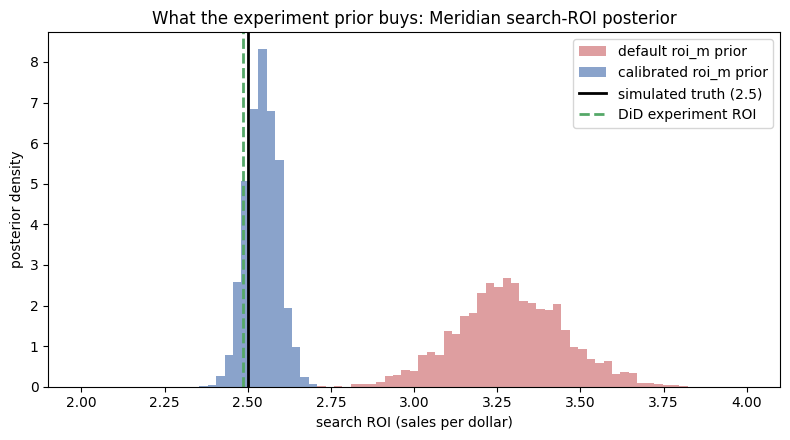

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(2.0, 4.0, 80)
ax.hist(roi_default.ravel(), bins=bins, density=True, alpha=0.55,
        label="default roi_m prior", color="#c44e52")
ax.hist(roi_calibrated.ravel(), bins=bins, density=True, alpha=0.65,
        label="calibrated roi_m prior", color="#4c72b0")
ax.axvline(BETA_SEARCH, color="black", lw=2, label="simulated truth (2.5)")
ax.axvline(prior.roi_mean, color="#55a868", lw=2, ls="--", label="DiD experiment ROI")
ax.set_xlabel("search ROI (sales per dollar)")
ax.set_ylabel("posterior density")
ax.set_title("What the experiment prior buys: Meridian search-ROI posterior")
ax.legend()
plt.tight_layout()
plt.show()

With the default prior the national model overcredits search - the launches rode
the demand ramp, and nationally there is no holdout to say otherwise. The
calibrated prior carries the geo experiment's information into the model: the
posterior centers on the truth and tightens.

## Acceptance checks

Sampler health first - the whole-model maximum R-hat (Meridian's own health-check
convention treats R-hat < 1.2 as converged) plus a tighter bar on the reported
`roi_m` for the experiment channel - then the calibration claims with slack
margins against draw noise.

In [9]:
for name, mer in [("default", mer_default), ("calibrated", mer_calibrated)]:
    post = mer.inference_data.posterior
    with warnings.catch_warnings():
        # constant/deterministic posterior variables have undefined R-hat;
        # arviz emits RuntimeWarnings computing them - excluded below.
        warnings.simplefilter("ignore", RuntimeWarning)
        rh_all = az.rhat(post)
    finite_rhats = np.concatenate(
        [np.asarray(rh_all[v]).ravel() for v in rh_all.data_vars]
    )
    max_rhat_model = float(finite_rhats[np.isfinite(finite_rhats)].max())
    rhat_roi = float(az.rhat(post["roi_m"]).sel(media_channel="search")["roi_m"])
    print(f"{name}: whole-model max Rhat={max_rhat_model:.4f}, "
          f"Rhat(roi_m, search)={rhat_roi:.4f}")
    # Meridian's own health-check convention treats Rhat < 1.2 as converged;
    # the reported ROI parameter is held to a tighter bar.
    assert np.isfinite(max_rhat_model) and max_rhat_model < 1.2, (
        f"{name} fit: some model parameter has not converged "
        f"(max Rhat {max_rhat_model:.4f})"
    )
    assert np.isfinite(rhat_roi) and rhat_roi < 1.05, (
        f"{name} fit: roi_m chains disagree (Rhat {rhat_roi:.4f}) - sampling is "
        "unhealthy here"
    )

flat_d, flat_c = roi_default.ravel(), roi_calibrated.ravel()
err_default = abs(flat_d.mean() - BETA_SEARCH)
err_calibrated = abs(flat_c.mean() - BETA_SEARCH)
width_default = float(np.quantile(flat_d, 0.95) - np.quantile(flat_d, 0.05))
width_calibrated = float(np.quantile(flat_c, 0.95) - np.quantile(flat_c, 0.05))
print(f"error: {err_default:.2f} -> {err_calibrated:.2f}; "
      f"90% width: {width_default:.2f} -> {width_calibrated:.2f}")

assert err_calibrated < err_default, (
    "calibrated ROI mean is not closer to the simulated truth - the experiment "
    "prior did not correct the bias in this environment"
)
assert width_calibrated < 0.8 * width_default, (
    "calibrated 90% interval is not clearly narrower - the experiment prior did "
    "not add information in this environment"
)
print("all acceptance checks passed")

default: whole-model max Rhat=1.0038, Rhat(roi_m, search)=0.9998


calibrated: whole-model max Rhat=1.0175, Rhat(roi_m, search)=1.0045
error: 0.79 -> 0.04; 90% width: 0.55 -> 0.15
all acceptance checks passed


## Where to go next

- **PyMC-Marketing**: notebook 29 runs the same hand-off as a *lift test* for a
  spend-boost experiment - the other classic geo design - including the grain
  reconciliation a non-total export needs.
- **API reference**: the `diff_diff.mmm` module documents `to_meridian_roi_prior`
  (spend-weighted pooling of multiple experiments, `se_widening`, `mroi_m`),
  `meridian_calibration_mask`, and `MeridianROIPrior.to_code` - including why
  channel order must match your `InputData` exactly, and Meridian's own guidance
  on when to prefer `full_model_window=True` over a calibration mask.
- **Estimator choices**: the DiD side works with any diff-diff estimator that
  supports `aggregate('total')` (CallawaySantAnna, EfficientDiD, ImputationDiD,
  TwoStageDiD).